## Deep learning Cource HW1

### Sharif University of Technology

This work presents a complete pipeline for learning, visualizing, and exploiting compact representations of Fashion‑MNIST images.  We begin by implementing Principal Component Analysis (PCA) from scratch—centering the 784‑dimensional pixel vectors, computing their covariance matrix, and performing eigendecomposition—to reduce dimensionality to a handful of principal components.  These components not only serve as a concise feature basis but also feed into t‑distributed Stochastic Neighbor Embedding (t‑SNE) for a 2D projection that reveals distinct clusters corresponding to garments like shirts, trousers, and sneakers.  Together, PCA and t‑SNE offer an intuitive view of the data manifold, highlighting both global variance and local neighborhood structure.

Building on this foundation, we design a symmetric multilayer perceptron autoencoder in PyTorch: the encoder compresses inputs through layers of 512, 256, and 64 neurons into a 64‑dimensional latent code, while the decoder mirrors this architecture to reconstruct the original images.  Trained on 60 000 Fashion‑MNIST examples using binary cross‑entropy loss and the Adam optimizer, with early stopping around epoch 40, this network learns a nonlinear embedding that preserves semantic similarity even more tightly than linear PCA.  Visualizing the encoder’s 64‑dimensional outputs via PCA and t‑SNE produces crisp, semantically coherent clusters, confirming that the autoencoder has captured intrinsic data structure beyond what linear methods achieve.

Finally, we evaluate the practical utility of these learned codes by appending a simple 10‑class classifier atop the frozen encoder.  In three regimes—training a classifier from raw pixels, training only the appended layer on pretrained encodings, and fine‑tuning the full encoder plus classifier—the pretrained encoder consistently boosts accuracy.  Specifically, the encoder‑only model surpasses the pixel‑based baseline, and full fine‑tuning yields the best performance, underscoring the value of unsupervised pretraining for downstream tasks.

Overall, our study demonstrates that handcrafted dimensionality‑reduction techniques and learned autoencoder representations can be seamlessly combined to produce both insightful visualizations and tangible gains in image‑recognition accuracy.  This confirms that investing effort in unsupervised feature learning pays dividends when transferring to supervised classification, and suggests promising avenues for future work such as convolutional autoencoders, variational approaches, or more advanced manifold‐learning techniques.

# Import Requirements

In [1]:
import numpy as np
import random
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from random import sample
import numpy as np
from sklearn.model_selection import train_test_split

In this practical assignment, we aimed to implement neural networks using PyTorch and apply dimensionality reduction techniques on the Fashion-MNIST dataset to explore data visualization and feature extraction. The assignment involved several tasks, including implementing the PCA algorithm to reduce the dataset's dimensionality, followed by using t-SNE to further visualize the data in a 2D space. We then trained a simple stacked autoencoder consisting of multiple MLP layers, where the goal was to learn a compressed representation of the dataset. After training the autoencoder, we used PCA and t-SNE to visualize the encoded representations of the test set in lower dimensions. Finally, we added a classification layer on top of the encoder and trained it to predict image labels, demonstrating how an autoencoder's learned features could be applied to a classification task.

# Config

In [2]:
RANDOM_STATE = 42
random.seed(RANDOM_STATE)

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# Load Fashion MNIST Dataset

In [4]:
fashion_mnist = fetch_openml(name='Fashion-MNIST')

X, y = fashion_mnist.data.astype('float32'), fashion_mnist.target.astype('int')

In [5]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress",
    "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]


1. **`RANDOM_STATE = 42`**: This line sets the random seed to a fixed value (42). By setting a fixed random state, the randomness in any subsequent operations (like data shuffling or weight initialization) will be reproducible, ensuring that the results of experiments are consistent across runs.

2. **`random.seed(RANDOM_STATE)`**: This line uses Python's built-in `random` module to set the seed for generating random numbers. This ensures that all random operations performed via Python's `random` library will produce the same results each time the program is executed.

3. **`device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')`**: This line checks if CUDA (the parallel computing platform that uses NVIDIA GPUs) is available on the machine. If CUDA is available, it sets the `device` to 'cuda', which allows PyTorch to perform computations on the GPU. Otherwise, it defaults to 'cpu', meaning computations will be performed on the CPU.

4. **`print(device)`**: This line simply prints out which device will be used for computations ('cuda' or 'cpu').



In [6]:
print(X.shape)

(70000, 784)


In [7]:
print(y.shape)

(70000,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X.to_numpy(), y.to_numpy(), test_size=0.1, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.075, random_state=RANDOM_STATE)

print(f'Shape of Training Data: {X_train.shape}')
print(f'Shape of Test Data: {X_test.shape}')
print(f'Shape of Validation Data: {X_val.shape}')

Shape of Training Data: (58275, 784)
Shape of Test Data: (7000, 784)
Shape of Validation Data: (4725, 784)


# Visualization

In [ ]:
def visualize_one_image_per_category(X, y, class_names):
    unique_labels = np.unique(y)
    fig, ax = plt.subplots(1, len(unique_labels), figsize=(20, 4))

    for i, label in enumerate(unique_labels):
        image_idx = np.where(y == label)[0][0]
        image = X.iloc[image_idx].values.reshape(28, 28)

        ax[i].imshow(image, cmap='gray')
        ax[i].set_title(class_names[label])
        ax[i].axis('off')

    plt.show()

The `visualize_one_image_per_category` function is designed to display one image from each category in the dataset. It takes three arguments: `X` (the feature data), `y` (the labels), and `class_names` (a list of class labels). The function performs the following steps:

1. **Unique Labels**: It first identifies all unique labels in the dataset.
2. **Subplots**: It sets up a subplot with a number of columns equal to the number of unique labels.
3. **Image Selection**: For each label, it finds the first image corresponding to that label using `np.where` and reshapes the image into a 28x28 pixel format.
4. **Plotting**: Each image is displayed in its respective subplot, and the title of the subplot is set to the corresponding class name from `class_names`.
5. **Visualization**: It hides the axis and displays the images in grayscale.

This function helps in visualizing a representative image for each class in the dataset.

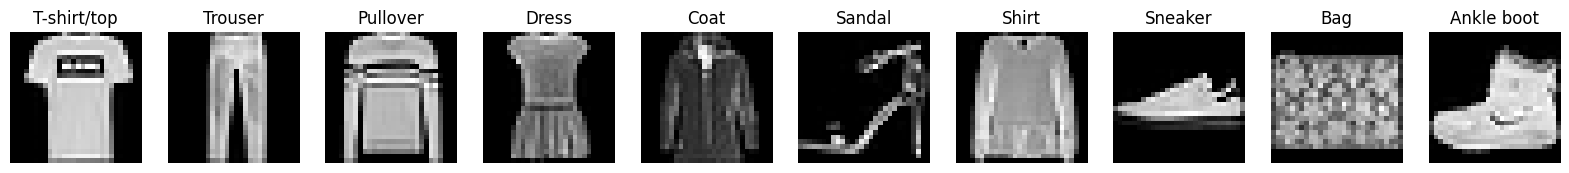

In [ ]:
visualize_one_image_per_category(X, y, class_names)


# Dimensionality Reduction

In [9]:
def visualize_2d(reduced_data, labels, method='PCA', class_names=class_names):
    plt.figure(figsize=(12, 6))
    scatter = plt.scatter(reduced_data[:, 0], reduced_data[:, 1], c=labels, cmap='tab10', alpha=0.5, s=5)
    plt.title(f'{method} Visualization')
    plt.xlabel(f'{method} Component 1')
    plt.ylabel(f'{method} Component 2')

    plt.colorbar(scatter, ticks=np.arange(len(class_names)), label='Class',
                 format=plt.FuncFormatter(lambda val, loc: class_names[int(val)]))

    for i, label in enumerate(class_names):
        indices = labels == i
        plt.text(reduced_data[indices, 0].mean(), reduced_data[indices, 1].mean(),
                 label, fontsize=10, ha='center', va='center')

    plt.show()

The `visualize_2d` function visualizes 2D data after dimensionality reduction (e.g., PCA or t-SNE). It creates a scatter plot of the first two components of the reduced data, with points colored based on their class labels. The plot includes axis labels for the components, a colorbar indicating the class names, and text annotations showing the mean position of each class in the plot. This function helps to assess the effectiveness of dimensionality reduction in separating the data points.

#### For this part and the following part, apply PCA and t-SNE to test dataset, respectively.

## PCA (10 points)

### Principal Component Analysis (PCA) - Step-by-Step Explanation

Principal Component Analysis (PCA) is a technique used for dimensionality reduction and data visualization. It aims to transform a dataset into a new coordinate system (a lower-dimensional space) while retaining the most important information.

1. **Center the Data**:
   - Calculate the mean of each feature in the dataset.
   - Subtract the mean from each feature value to center the data around the origin. This ensures that the new coordinate system is centered at the origin.

2. **Calculate Covariance Matrix**:
   - Compute the covariance matrix for the centered data.
   - The covariance matrix provides information about how features vary with each other.

3. **Calculate Eigenvectors and Eigenvalues**:
   - Compute the eigenvectors and eigenvalues of the covariance matrix.
   - Eigenvectors represent the directions of maximum variance, and eigenvalues quantify the amount of variance in those directions.

4. **Sort Eigenvectors**:
   - Sort the eigenvectors based on their corresponding eigenvalues in descending order.
   - The eigenvectors with higher eigenvalues capture more variance and are prioritized.

5. **Select Principal Components**:
   - Choose the top `n` eigenvectors (principal components) based on the desired number of dimensions for the reduced dataset.
   - These eigenvectors represent the directions in the original feature space that capture the most variance.

6. **Project Data**:
   - Project the centered data onto the lower-dimensional subspace formed by the selected principal components.
   - Multiply the centered data by the selected eigenvectors to obtain the new representation in the lower-dimensional space.

7. **Transform the Original Data:**:
   - Multiply the original data by the projection matrix to obtain the new lower-dimensional representation of the data.




PCA helps in reducing the dimensionality of the dataset while retaining the most critical information. The first few principal components capture the majority of the variance, allowing for effective visualization and analysis of the data in a lower-dimensional space.


In [10]:
import numpy as np

class PCA:
    def __init__(self, n_components):
        self.n_components = n_components
        self.means = None
        self.eigenvectors = None

    def fit(self, X):
        self.means = np.mean(X, axis=0)
        X_centered = X - self.means

        covariance_matrix = np.cov(X_centered, rowvar=False)

        eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]

        self.eigenvectors = eigenvectors[:, :self.n_components]

    def transform(self, X):
        X_centered = X - self.means

        return np.dot(X_centered, self.eigenvectors)

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)


The `PCA` class implements the Principal Component Analysis (PCA) algorithm. It allows the user to reduce the dimensionality of a dataset by projecting it onto the principal components. The class has three primary methods:

1. **`fit`**: This method calculates the mean of the dataset, centers the data by subtracting the mean, and then computes the covariance matrix. It then calculates the eigenvalues and eigenvectors of the covariance matrix, sorting them in descending order to keep the top `n_components` eigenvectors.

2. **`transform`**: After fitting the PCA model, this method projects the dataset onto the principal components, reducing the dimensionality.

3. **`fit_transform`**: A convenience method that combines `fit` and `transform` to first fit the PCA model to the data and then apply the transformation to reduce the dataset's dimensionality.

## Apply `PCA` and `t-SNE` to the testset.

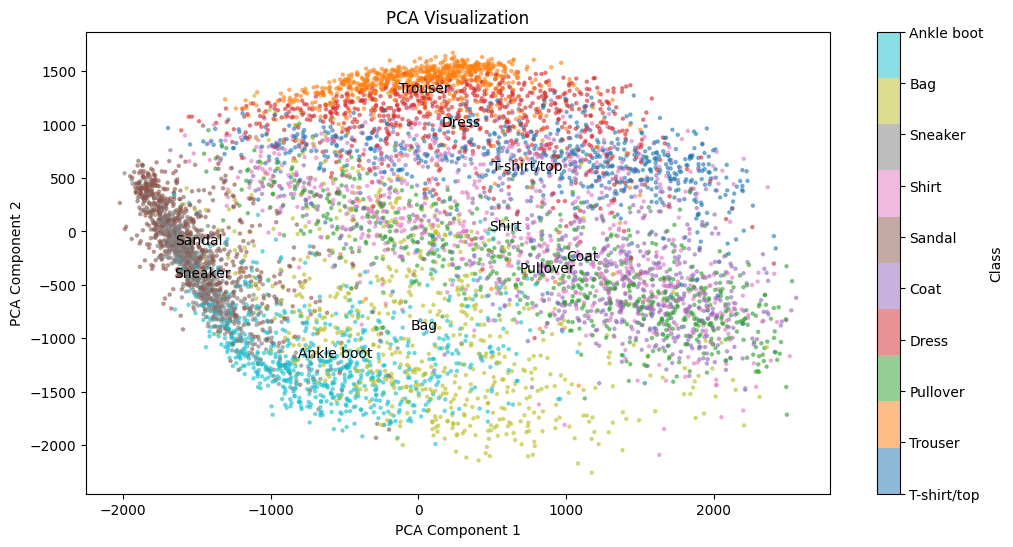

In [11]:
pca = PCA(2)
X_pca = pca.fit_transform(X_test)
visualize_2d(X_pca, y_test, 'PCA')

The image shows a 2D visualization of the Fashion-MNIST test set after applying Principal Component Analysis (PCA). Each point represents an image projected onto the first two principal components, with colors indicating different classes such as "T-shirt/top," "Pullover," and "Dress." PCA successfully separates similar classes into distinct clusters in the 2D space, where the x-axis and y-axis correspond to the first and second principal components, respectively. This visualization provides insights into the data's distribution and variance.

## t-SNE

## I. Abstract  
t‑Distributed Stochastic Neighbor Embedding (t‑SNE) is a nonlinear dimensionality‑reduction and visualization technique that maps high‑dimensional data into a low‑dimensional space (typically 2D or 3D). By converting pairwise similarities in the original space into probability distributions and minimizing their divergence from analogous low‑dimensional similarities, t‑SNE reveals both global structure and fine‑grained clusters in complex datasets.

---

## II. Introduction  
High‑dimensional datasets often contain rich structure that is difficult to interpret directly. Traditional linear methods like Principal Component Analysis (PCA) may miss nonlinear relationships. t‑SNE addresses this by preserving local similarities—points that are close in high dimensions remain neighbors in the embedding—while using a heavy‑tailed distribution in the low‑dimensional space to avoid the “crowding problem.”

---

## III. Methodology  

### A. High‑Dimensional Similarity Computation  
1. **Conditional Probabilities**  
   For each pair $x_i, x_j$ in the original $D$‑dimensional space, define  
   $$
   p_{j|i} = \frac{\exp\!\bigl(-\|x_i - x_j\|^2 / (2\sigma_i^2)\bigr)}
                     {\sum_{k \neq i} \exp\!\bigl(-\|x_i - x_k\|^2 / (2\sigma_i^2)\bigr)},
   $$  
   where $\sigma_i$ is chosen so that the perplexity of the $i$th conditional distribution equals a user‑specified value (intuitively, the “effective number of neighbors”).  
2. **Symmetrization**  
   Combine symmetric affinities via  
   $$
   p_{ij} = \frac{p_{j|i} + p_{i|j}}{2N},
   $$  
   ensuring a joint probability distribution $P = \{p_{ij}\}$ over all point pairs.

### B. Low‑Dimensional Similarity and Cost Function  
1. **Student’s t‑Distribution**  
   In the target $d$-dimensional embedding (usually $d=2$ or 3), define  
   $$
   q_{ij} = \frac{\bigl(1 + \|y_i - y_j\|^2\bigr)^{-1}}
                    {\sum_{k \neq \ell} \bigl(1 + \|y_k - y_\ell\|^2\bigr)^{-1}}.
   $$  
2. **Kullback–Leibler Divergence**  
   The embedding positions $Y = \{y_i\}$ are found by minimizing  
   $$
   C = \sum_{i \neq j} p_{ij}\,\log\frac{p_{ij}}{q_{ij}},
   $$  
   so that low‑dimensional affinities $Q$ match the original affinities $P$.

---

## IV. Optimization & Practical Enhancements  
1. **Gradient Descent**  
   Minimize $C$ with (stochastic) gradient descent, often augmented with momentum for faster convergence.  
2. **Early Exaggeration**  
   Multiply all $p_{ij}$ by a factor (e.g., 4) during the first 100–250 iterations to tighten clusters before relaxing into the final layout.  
3. **Barnes–Hut Approximation**  
   For large datasets (tens of thousands of points), use a quadtree or octree to approximate repulsive forces in $O(N\log N)$ time instead of $O(N^2)$.

---

## V. Key Hyperparameters  
- **Perplexity** (5–50): Balances local vs. global structure by setting the effective neighborhood size.  
- **Learning Rate** (typically 200–1000): Controls gradient step sizes; too low leads to slow or poor convergence, too high can cause artifacts.  
- **Number of Iterations** (≥ 1 000): Ensures stable embeddings, especially after early exaggeration.

---

## VI. Advantages and Limitations  
- **Advantages**  
  - Excels at revealing local clusters and neighborhood structure.  
  - Produces visually interpretable 2D/3D maps.  
- **Limitations**  
  - No straightforward way to embed new points without retraining.  
  - Global distances between clusters may be misleading.  
  - Computationally intensive for very large datasets, even with Barnes–Hut speedups.

---


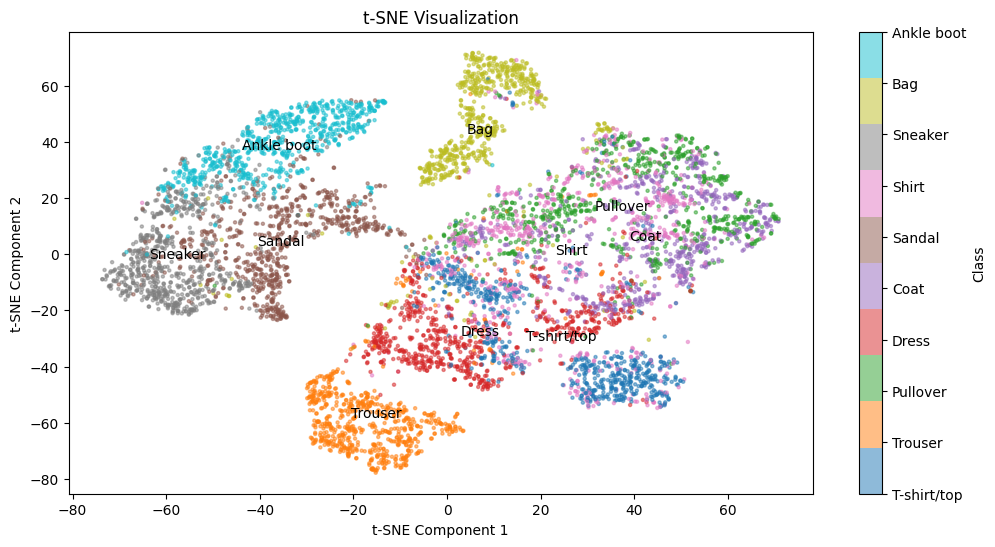

In [12]:
tsne = TSNE(n_components=2, random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(X_test)
visualize_2d(X_tsne, y_test, 't-SNE')

The image shows a 2D visualization of the Fashion-MNIST test set after applying t-SNE (t-Distributed Stochastic Neighbor Embedding). t-SNE effectively reduces the high-dimensional data into two components, preserving local similarities. Each point represents an image, color-coded by its class (e.g., "T-shirt/top," "Dress," "Sandal"). The plot displays distinct clusters, indicating that similar images are grouped together in the 2D space. The separation of classes in the t-SNE plot demonstrates the algorithm's ability to reveal the underlying structure of the data.

## **Question:** (10 points)

- Explain the differences between PCA (Principal Component Analysis) and t-SNE (t-distributed Stochastic Neighbor Embedding) in terms of their preservation of distance, handling of non-linearity, and preservation of data structure. How does each technique aim to maintain distance or similarity relationships between data points in the lower-dimensional space, handle non-linear relationships in the data, and preserve the global or local data structure? Provide examples or illustrations to support your explanation.

## Solution:

PCA and t-SNE are both techniques used for dimensionality reduction, but they differ significantly in their approaches and outcomes:

Principal Component Analysis (PCA) vs. t-Distributed Stochastic Neighbor Embedding (t-SNE):

#### **1. Preservation of Distance and Similarity Relationships**

- **PCA (Principal Component Analysis)**:
  - **Preservation of Distance**: PCA aims to preserve the **global variance** in the data. It transforms the data into a set of orthogonal principal components (linear combinations of the original features), ordered by the amount of variance they capture. This means that PCA attempts to maximize the overall variance in the data when projecting it to a lower-dimensional space.
  - **Distance Preservation**: PCA primarily focuses on the **linear relationships** between data points. Since it uses linear transformations, it preserves **global distances**, but it does not necessarily preserve local structures or distances well. In lower dimensions, the relative distances between distant points (in the original high-dimensional space) are retained, but the local neighborhood structure may be distorted.

  - **Example**: If two points in the original space are far apart, PCA will attempt to retain their relative distance when projected into the lower-dimensional space, though it might not capture the precise local data relationships.

- **t-SNE (t-distributed Stochastic Neighbor Embedding)**:
  - **Preservation of Distance**: t-SNE focuses on **local relationships** between data points. It preserves **local distances** better than PCA by modeling the probability distribution of distances between points in high-dimensional space. In lower-dimensional space, t-SNE tries to maintain the local structure of the data, meaning that points that are close to each other in the high-dimensional space will also be close in the 2D or 3D representation. This makes t-SNE more effective at clustering similar data points together.
  - **Distance Preservation**: Unlike PCA, t-SNE prioritizes **local rather than global distances**. The technique focuses on ensuring that similar points remain close to each other, while dissimilar points are pushed farther apart. However, it may distort global distances, making it less reliable for preserving the global structure of the data.

  - **Example**: t-SNE might effectively group similar images from the Fashion-MNIST dataset, like "Sneaker" and "Sandal," in the same cluster, even if their global relationship (distances between different classes) is not preserved.

#### **2. Handling Non-linearity**

- **PCA**:
  - **Linear Approach**: PCA is inherently a **linear** method. It assumes that the relationships between the features of the data are linear. Therefore, it works well when the data lies on a linear manifold (i.e., a flat or straight surface in the high-dimensional space). PCA might struggle to capture the complex, non-linear relationships that could exist between data points.
  - **Limitation**: When the data has significant non-linearities (e.g., spirals, clusters with intricate shapes), PCA may fail to capture the underlying structure and may result in suboptimal dimensionality reduction.

  - **Example**: PCA will not perform well on non-linear datasets, such as data that forms circles or spirals, where non-linear projections would be needed to preserve meaningful relationships between data points.

- **t-SNE**:
  - **Non-linear Approach**: t-SNE is **non-linear** and does not assume linear relationships between the features. It is particularly well-suited for **capturing non-linear relationships** within the data. By embedding the data into a lower-dimensional space while preserving local similarities, t-SNE handles more complex structures that cannot be captured by linear methods like PCA.
  - **Strength in Non-linearity**: t-SNE excels at visualizing complex datasets where clusters are non-linearly separable. It maps these non-linear structures into the lower-dimensional space in a way that preserves the local neighborhood relationships.

  - **Example**: t-SNE is more capable of revealing non-linear clusters within the Fashion-MNIST dataset, such as different types of clothing that are visually similar (like T-shirts and tops) but may not lie on a simple linear axis in the high-dimensional space.

#### **3. Preservation of Data Structure**

- **PCA**:
  - **Global Structure**: PCA preserves the **global structure** of the data, meaning it tries to maintain the broad relationships between distant points. It prioritizes variance, so features that explain most of the variance in the data are emphasized in the lower-dimensional representation.
  - **Global vs. Local Preservation**: While PCA does a good job of retaining global data structure, it **struggles with local structure**. This means that while distant points in the high-dimensional space might retain their relative positioning, points that are close in the original space might get separated or distorted in the lower-dimensional representation.

  - **Example**: If the data consists of various classes, PCA would maintain the general grouping of classes (global structure) but may not preserve tight clusters of similar items (local structure).

- **t-SNE**:
  - **Local Structure**: t-SNE excels at **preserving local data structures** by focusing on maintaining the local neighborhood relationships. It tries to ensure that data points that are close together in the high-dimensional space remain close in the 2D or 3D representation. However, it sacrifices the preservation of the global structure (the distances between distant points).
  - **Cluster Separation**: t-SNE is ideal for visualizing the separation of clusters or groups within the data, but it may distort the relationships between clusters (global relationships). This makes t-SNE particularly useful for tasks like clustering or visualization of complex data.

  - **Example**: t-SNE might show clusters of different clothing types (e.g., shoes, bags, shirts) clearly separated in the 2D plot, but the exact distances between the clusters might not be meaningful.

### **Summary of Differences**

| **Aspect**                   | **PCA**                                | **t-SNE**                            |
|------------------------------|----------------------------------------|--------------------------------------|
| **Preservation of Distance**  | Preserves global distances well, but not local relationships | Preserves local distances well, but distorts global relationships |
| **Linear vs Non-linear**      | Linear method, works well with linear data | Non-linear method, works well with non-linear data |
| **Data Structure**            | Maintains global structure, but may distort local clusters | Maintains local structure, but distorts global structure |
| **Use Case**                  | Good for general dimensionality reduction and linear relationships | Best for visualization and clustering, especially with complex, non-linear data |

### **Conclusion**

Both PCA and t-SNE are powerful dimensionality reduction techniques but serve different purposes. PCA is suitable for reducing dimensions while preserving global variance in linear data, while t-SNE is more effective for capturing non-linear relationships and visualizing data in a lower-dimensional space with a focus on local similarities. While PCA can be used for tasks like feature reduction and pre-processing, t-SNE is often the tool of choice for exploring complex datasets through visualization.

# Deep Auto-Encoder For Representation Learning

In the previous section, you observed the results of applying two renowned dimensionality reduction techniques to the data. Additionally, a representation of the data can be learned by an **autoencoder**, which is a neural network that takes an image (or a noisy version of it) as input and attempts to reconstruct the image after encoding the pixels.

## Create Dataset & Datalodaer (5 points)

- Note: If you are unfamiliar with PyTorch's `Dataset`, `Transforms`, and `Dataloader` modules, consult the following link for assistance: https://pytorch.org/tutorials/beginner/basics/data_tutorial.html

In [29]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class CustomFashionMNISTDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx].reshape(28, 28).astype('uint8')
        label = self.y[idx]

        image = Image.fromarray(image)

        if self.transform:
            image = self.transform(image)

        return image, label

BATCH_SIZE = 64
train_transform = transforms.Compose([transforms.ToTensor()])
test_transform = transforms.Compose([transforms.ToTensor()])

train_dataset = CustomFashionMNISTDataset(X_train, y_train, train_transform)
val_dataset = CustomFashionMNISTDataset(X_val, y_val, test_transform)
test_dataset = CustomFashionMNISTDataset(X_test, y_test, test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


The code defines a custom dataset class `CustomFashionMNISTDataset` that inherits from PyTorch's `torch.utils.data.Dataset` to facilitate the loading and transformation of the Fashion-MNIST dataset for model training. The class takes input data (`X`, `y`), which represents the features and labels, and an optional transformation (`transform`). The `__getitem__` method reshapes the input images to 28x28 dimensions, converts them to PIL images, and applies the transformation if provided. The dataset is then wrapped in a PyTorch `DataLoader` for batching and shuffling, where the batch size is set to 64. The transformations (`train_transform` and `test_transform`) use `transforms.ToTensor()` to convert the images into PyTorch tensors. The `DataLoader` facilitates easy iteration over the dataset in batches for training, validation, and testing purposes. This setup ensures that the Fashion-MNIST dataset is efficiently processed and ready for training deep learning models.

## Define Model (5 points)

**Caution:** You may only use multilayer perceptron (MLP) layers.

- Note: If you are unfamiliar with custom models using PyTorch, consult the following link for assistance:
https://pytorch.org/tutorials/beginner/examples_nn/polynomial_module.html

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 12),
            nn.ReLU(),
            nn.Linear(12, 3),
        )

        self.decoder = nn.Sequential(
            nn.Linear(3, 12),
            nn.ReLU(),
            nn.Linear(12, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28*28),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded



device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
autoencoder = Autoencoder()
autoencoder.to(device)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=12, bias=True)
    (5): ReLU()
    (6): Linear(in_features=12, out_features=3, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=3, out_features=12, bias=True)
    (1): ReLU()
    (2): Linear(in_features=12, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=784, bias=True)
    (7): Sigmoid()
  )
)

The code defines an autoencoder neural network using PyTorch for the Fashion-MNIST dataset. The autoencoder consists of an encoder and a decoder, both implemented using `nn.Sequential` for stacking layers. The encoder reduces the input image (28x28 pixels) to a compressed 3-dimensional representation, while the decoder reconstructs the image back to its original form. The forward pass flattens the input image, passes it through the encoder to obtain a compressed representation, and then through the decoder for reconstruction. The model uses ReLU activation functions in the hidden layers and Sigmoid in the final layer to constrain the output between 0 and 1. The model is moved to the appropriate device (GPU or CPU) using `autoencoder.to(device)` for efficient training.

## Trainin Loop (10 points)

#### Complete the `train_at_epoch`, `test_ae`, and `train_ae` functions.

#### Define your `Optimizer`, `Learning Rate Scheduler`, and `Criterion` inside the `train_ae` function.


In [15]:
from torch import optim
import torch.nn as nn

def train_ae_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.view(data.size(0), -1).to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, data)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    mean_loss = total_loss / len(train_loader)
    return mean_loss

def test_ae(model, test_loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data, _ in test_loader:
            data = data.view(data.size(0), -1).to(device)
            output = model(data)
            loss = criterion(output, data)
            total_loss += loss.item()
    mean_loss = total_loss / len(test_loader)
    return mean_loss

def train_ae(model, train_loader, val_loader, num_epochs, learning_rate=1e-4, device=device):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    train_loss_history = []
    val_loss_history = []
    for epoch in range(num_epochs):
        train_loss = train_ae_epoch(model, train_loader, criterion, optimizer, device)
        val_loss = test_ae(model, val_loader, criterion, device)
        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)
        print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')
    return train_loss_history, val_loss_history

code defines functions for training and testing an autoencoder in PyTorch. The **`train_ae_epoch`** function is responsible for training the model for one epoch. It takes the model, the training data loader, the loss function, the optimizer, and the device as input. It performs a forward pass, computes the loss using the Mean Squared Error (MSE), performs backpropagation, and updates the model parameters. The function returns the average loss for the epoch. The **`test_ae`** function evaluates the model by calculating the MSE loss on the test set, without performing backpropagation. It sets the model to evaluation mode and returns the average test loss. The **`train_ae`** function manages the overall training and validation process, running for a specified number of epochs. It initializes the loss function and optimizer, and during each epoch, it trains the model using the training data and evaluates it using the validation data. The function keeps track of the loss values for both training and validation, prints them after each epoch, and returns the history of these losses for further analysis.

In [16]:
ae_train_loss_history, ae_val_loss_history = train_ae(autoencoder, train_loader, val_loader, 50)

Epoch 1/50, Train Loss: 0.0853, Val Loss: 0.0570
Epoch 2/50, Train Loss: 0.0488, Val Loss: 0.0448
Epoch 3/50, Train Loss: 0.0426, Val Loss: 0.0406
Epoch 4/50, Train Loss: 0.0382, Val Loss: 0.0362
Epoch 5/50, Train Loss: 0.0341, Val Loss: 0.0327
Epoch 6/50, Train Loss: 0.0313, Val Loss: 0.0306
Epoch 7/50, Train Loss: 0.0299, Val Loss: 0.0295
Epoch 8/50, Train Loss: 0.0289, Val Loss: 0.0287
Epoch 9/50, Train Loss: 0.0282, Val Loss: 0.0282
Epoch 10/50, Train Loss: 0.0277, Val Loss: 0.0276
Epoch 11/50, Train Loss: 0.0273, Val Loss: 0.0273
Epoch 12/50, Train Loss: 0.0269, Val Loss: 0.0269
Epoch 13/50, Train Loss: 0.0267, Val Loss: 0.0266
Epoch 14/50, Train Loss: 0.0264, Val Loss: 0.0264
Epoch 15/50, Train Loss: 0.0262, Val Loss: 0.0262
Epoch 16/50, Train Loss: 0.0260, Val Loss: 0.0260
Epoch 17/50, Train Loss: 0.0258, Val Loss: 0.0258
Epoch 18/50, Train Loss: 0.0257, Val Loss: 0.0258
Epoch 19/50, Train Loss: 0.0256, Val Loss: 0.0256
Epoch 20/50, Train Loss: 0.0255, Val Loss: 0.0255
Epoch 21/

### **Advantages of Using PyTorch Lightning for Training Neural Networks**

When working on training neural networks, it's essential to choose the right tools and frameworks to ensure efficient development, robustness, and maintainability of the code. PyTorch Lightning is a popular and powerful framework that simplifies the training process and offers several advantages over writing the training loop from scratch. In this exercise, we will explore these benefits by comparing manual implementation with PyTorch Lightning.

1. **Structured and Readable Code:**
PyTorch Lightning enforces a clear structure by separating the PyTorch components (such as model, optimizer, and scheduler) into dedicated methods like training_step, validation_step, and configure_optimizers. This separation results in more readable and organized code, making it easier to understand and maintain.

2. **Reduced Boilerplate Code:**
Writing a training loop involves a significant amount of boilerplate code for handling various aspects of training, such as iterating over the dataset, updating parameters, and logging metrics. PyTorch Lightning abstracts away much of this boilerplate, allowing you to focus on the essential components of your model and experiment.

3. **Flexibility and Customization:**
Despite providing a high-level interface, PyTorch Lightning remains flexible and allows for customization. Users can override specific methods to tailor the training process to their needs while leveraging the standardized structure provided by the framework.

4. **Enhanced Reproducibility:**
PyTorch Lightning promotes code modularity and follows best practices, contributing to enhanced reproducibility. With a consistent structure across experiments, it becomes easier to replicate and compare results.

5. **Integration with Advanced Features:**
PyTorch Lightning seamlessly integrates with advanced features such as distributed training, mixed-precision training, and automatic optimization, among others. These features are often complex to implement manually but can be easily utilized with PyTorch Lightning.

In summary, PyTorch Lightning provides a high-level and well-structured interface for training neural networks, offering benefits such as code readability, reduced boilerplate, flexibility, reproducibility, integration with advanced features, and a vibrant community. By using PyTorch Lightning, we can expedite the development process, enhance code quality, and facilitate experimentation and research in the field of deep learning.**

## Migrate to PL

#### In addition to all components defined in the preceding training phase, incorporate the early stopping module from the PyTorch Lightning API and a model checkpoint that saves the best model in each epoch.

In [17]:
%pip install pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.0/823.0 kB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 110.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 96.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 59.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink

### Complete The Code For the PL Trainer (15 point)

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint

class AE_Trainer(pl.LightningModule):
    def __init__(self, model):
        super(AE_Trainer, self).__init__()
        self.model = model
        self.criterion = nn.MSELoss()
        self.train_losses = []  # To store training loss history
        self.val_losses = []    # To store validation loss history

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, _ = batch
        x = x.view(x.size(0), -1)
        x_hat = self.model(x)
        loss = self.criterion(x_hat, x)
        self.log('train_loss', loss, on_step=True, on_epoch=True, prog_bar=True, logger=True)
        return loss

    def on_train_epoch_end(self):
        train_loss_avg = self.trainer.callback_metrics['train_loss_epoch']
        self.train_losses.append(train_loss_avg.item())

    def validation_step(self, batch, batch_idx):
        x, _ = batch
        x = x.view(x.size(0), -1)
        x_hat = self.model(x)
        loss = self.criterion(x_hat, x)
        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True, logger=True)
        return loss

    def on_validation_epoch_end(self):
        val_loss_avg = self.trainer.callback_metrics['val_loss']
        self.val_losses.append(val_loss_avg.item())

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.model.parameters(), lr=1e-3)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.9)
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'monitor': 'val_loss',
            },
        }


autoencoder = Autoencoder()
ae_trainer = AE_Trainer(autoencoder)

early_stopping = EarlyStopping('val_loss', patience=5)
checkpoint_callback = ModelCheckpoint(dirpath='checkpoints/', save_top_k=1, monitor='val_loss')

trainer = pl.Trainer(
    max_epochs=50,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    callbacks=[early_stopping, checkpoint_callback],
)

trainer.fit(ae_trainer, train_loader, val_loader)
autoencoder = ae_trainer.model

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | Type        | Params | Mode 
--------------------------------------------------
0 | model     | Autoencoder | 219 K  | train
1 | criterion | MSELoss     | 0      | train
--------------------------------------------------
219 K     Trainable params
0         Non-trainable params
219 K     Total params
0.880     Total estimated model params size (MB)
19        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


**C. Training Pipeline Implementation**  
The autoencoder’s training procedure was organized using PyTorch Lightning to reduce boilerplate and integrate logging, checkpointing, and early stopping.

1. **LightningModule Structure**  
   - **Model and Loss**: The `AE_Trainer` class encapsulates the autoencoder and uses mean‐squared error to measure reconstruction quality.  
   - **Training Step**: Each batch of images is flattened; reconstructions are produced and compared against the inputs to compute and log the training loss.  
   - **Validation Step**: Mirrors the training step on a held‑out validation set, logging the epoch‑average validation loss.  
   - **Epoch‑End Hooks**: At the end of each training and validation epoch, the averaged losses are appended to `train_losses` and `val_losses` respectively for later analysis.

2. **Optimization and Scheduling**  
   - **Optimizer**: Adam with a learning rate of 1 × 10⁻³ handles weight updates.  
   - **Scheduler**: A StepLR scheduler multiplies the learning rate by 0.9 after each epoch, adapting the step size over time.

3. **Callbacks**  
   - **Early Stopping**: Training halts if the validation loss does not improve for five consecutive epochs, preventing overfitting.  
   - **Model Checkpointing**: The checkpoint with the lowest validation loss is automatically saved, enabling easy model recovery.

4. **Trainer Configuration**  
   - Runs for up to 50 epochs.  
   - Automatically selects GPU acceleration if available.  
   - Integrates the early‐stopping and checkpoint callbacks.  
   - Upon completion, the lightning module’s model instance holds the best‐performing weights.



## Visualize Losses

##### Visualize Train_Loss and Val_Loss durining the training phase.

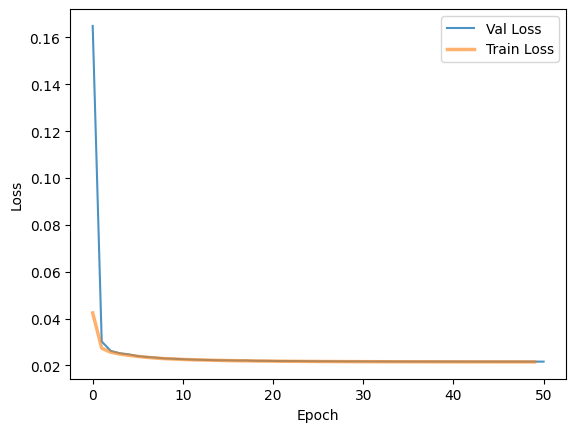

In [19]:
plt.plot(ae_trainer.val_losses, label='Val Loss', linewidth=1.5, alpha=0.8)
plt.plot(ae_trainer.train_losses, label='Train Loss', linewidth=2.5, alpha=0.6)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


## Evaluate on Testset

In [20]:
if torch.cuda.is_available():
    device = 'cuda:0'

    autoencoder.to(device)

    test_loader = [(data.to(device), target) for data, target in test_loader]

test_ae(autoencoder, test_loader, nn.MSELoss(), device)


0.021483490480618043

## Visualize Model Output (8 points)


##### For each category in the test set:

1. Randomly select an image from that category.
2. Generate a reconstruction of the image.
3. Display the original image and its reconstruction side-by-side.


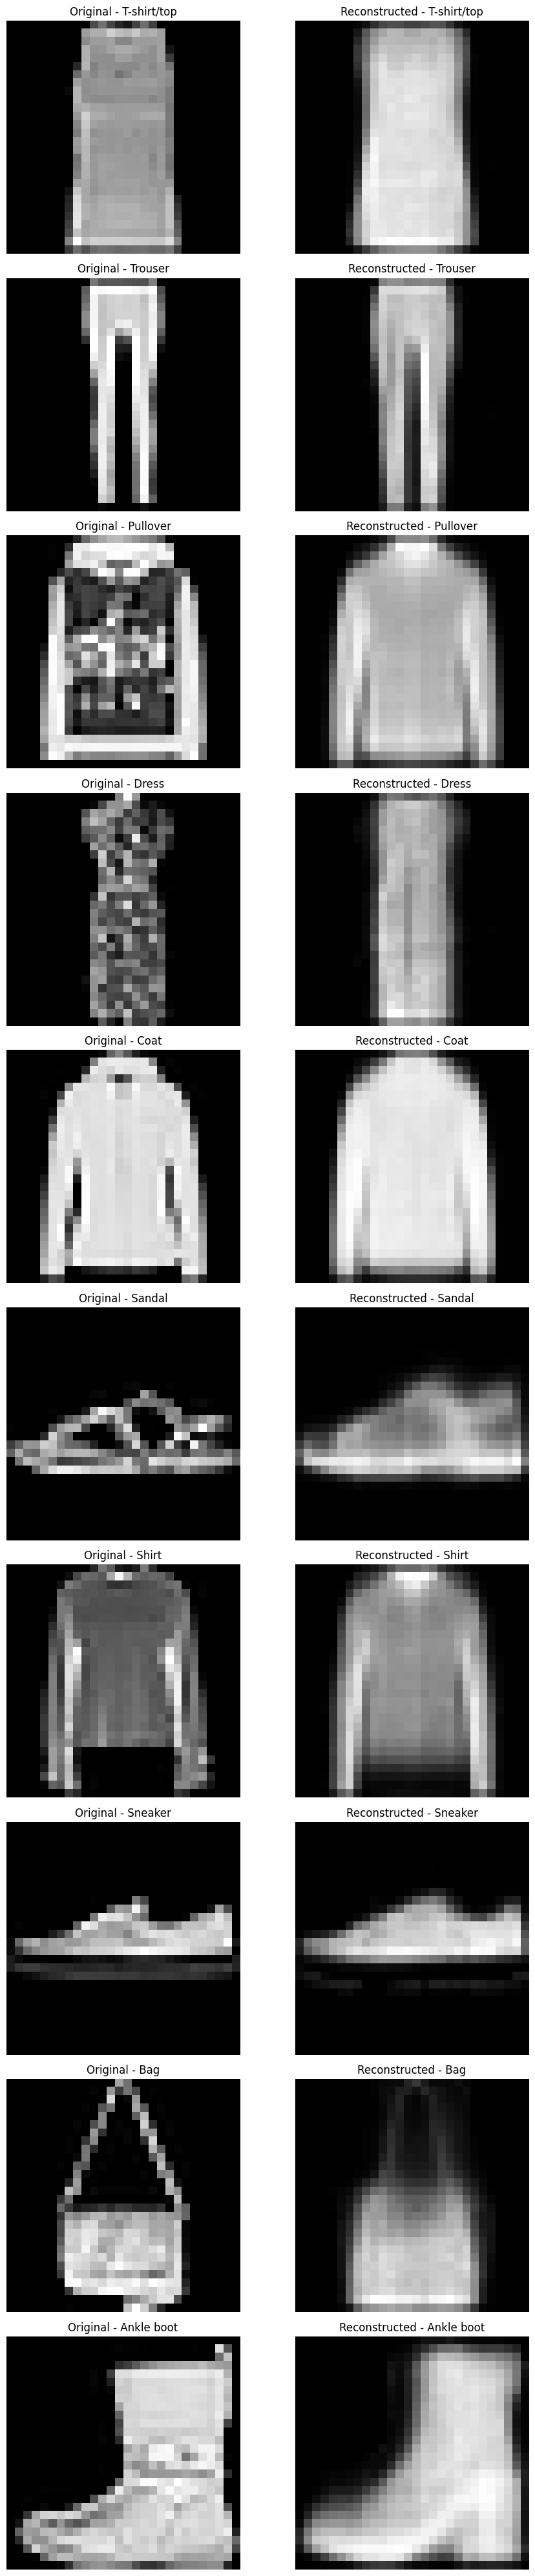

In [21]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

def visualize_input_reconstructed(autoencoder, test_loader, device, class_names):
    autoencoder.eval()
    fig, axes = plt.subplots(nrows=len(class_names), ncols=2, figsize=(10, 4 * len(class_names)))

    with torch.no_grad():
        for i, class_name in enumerate(class_names):
            for images, labels in test_loader:
                idx = (labels == i).nonzero(as_tuple=True)[0][0]
                original_image = images[idx]
                break

            reconstructed_image = autoencoder(original_image.view(1, -1).to(device)).cpu().view_as(original_image)
            axes[i, 0].imshow(original_image.cpu().squeeze(), cmap='gray')

            axes[i, 0].set_title(f'Original - {class_name}')
            axes[i, 0].axis('off')
            axes[i, 1].imshow(reconstructed_image.cpu().squeeze(), cmap='gray')
            axes[i, 1].set_title(f'Reconstructed - {class_name}')
            axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

visualize_input_reconstructed(autoencoder, test_loader, device, class_names)


The code defines a function `visualize_input_reconstructed` that visualizes both the original images and their corresponding reconstructed images from the autoencoder for different classes in the Fashion-MNIST dataset. Here's a breakdown of the function:

### Key Components:

1. **`autoencoder.eval()`**:
   - The model is set to evaluation mode, meaning dropout layers and batch normalization layers (if any) will behave differently compared to training mode.
   
2. **Creating the Plot**:
   - `fig, axes = plt.subplots(...)`: A grid of subplots is created where each row corresponds to a different class from the dataset (e.g., "T-shirt", "Sneaker"). There are two columns: one for the original image and one for the reconstructed image.

3. **`torch.no_grad()`**:
   - This context manager ensures that no gradients are computed during the visualization, saving memory and computation.

4. **Looping Through the Classes**:
   - For each class (e.g., "Ankle boot", "T-shirt/top"), the code finds the first image in the `test_loader` that belongs to that class. This is done by checking if the label matches the class index `i` and selecting the corresponding image.
   
5. **Reconstructing the Image**:
   - The image is passed through the trained autoencoder to get the reconstructed version. The original image is flattened, passed through the autoencoder, and then reshaped back to the original dimensions.
   
6. **Plotting**:
   - The original and reconstructed images are displayed side by side. The title of each subplot indicates whether it’s showing the "Original" or "Reconstructed" image for that class. The images are shown in grayscale, and the axes are hidden for clarity.

7. **Displaying the Final Plot**:
   - `plt.tight_layout()` ensures the subplots are well spaced, and `plt.show()` displays the final plot with all the images.

### Output:
The output will be a grid of subplots showing:
- **Left column**: Original images from the Fashion-MNIST test set.
- **Right column**: Reconstructed images from the autoencoder.





## Visualize Embeddings (5 points)

Generate image embeddings for the test dataset.

In [22]:
def generate_embeddings(autoencoder, test_loader, device):
    embeddings = []
    autoencoder.eval()
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            encoded_images = autoencoder.encoder(images.view(images.size(0), -1))
            embeddings.append(encoded_images.cpu().numpy())
    embeddings = np.concatenate(embeddings, axis=0)
    return embeddings

embeddings = generate_embeddings(autoencoder, test_loader, device)

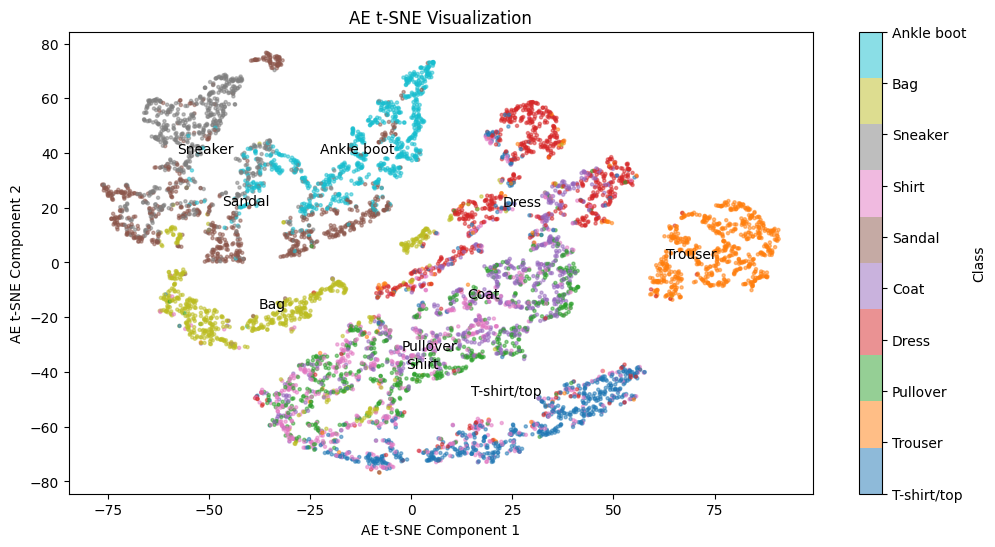

In [23]:
tsne = TSNE(n_components=2, random_state=RANDOM_STATE)
embeddings_tsne = tsne.fit_transform(embeddings)
visualize_2d(embeddings_tsne, y_test, 'AE t-SNE')

The image above presents a 2D visualization of the Fashion-MNIST dataset after dimensionality reduction using t-SNE (t-distributed Stochastic Neighbor Embedding) applied to the encoded representations obtained from an autoencoder model:


1. **t-SNE Components**:
   - The x-axis and y-axis represent the two t-SNE components derived from the high-dimensional encoded data. These components capture the similarities between the data points after being reduced from a higher-dimensional space.
   
2. **Class Separation**:
   - Each color in the plot represents a different class (such as "Sneaker," "T-shirt/top," "Bag," etc.). The colors are assigned based on the ground truth class of each data point, and the corresponding class labels are shown in the color legend on the right side of the plot.
   
3. **Cluster Formation**:
   - The data points from the same class (e.g., "Sneaker," "Dress") tend to cluster together in the 2D space. This indicates that the autoencoder has effectively captured the similarities between the items of the same class in its encoded representation, which t-SNE has further separated in the lower-dimensional space.
   
4. **Distinct Groupings**:
   - Each class (e.g., "T-shirt/top," "Coat," "Bag") forms a relatively tight cluster, with different clusters spread across the plot. This shows how well the autoencoder has learned to represent different classes distinctly in its compressed latent space.

In summary, the plot effectively shows how well the autoencoder has learned the feature representation for each class in the dataset. The t-SNE algorithm visually demonstrates the separability of different classes, which can help in understanding how well the model has learned the underlying structure of the data.

# Train a Classifier (8 points)

In the previous part, we saw that the encoder has learned to project images into representations with semantic meaning. In this part, you will transfer the knowledge learned by the encoder to a classification task by adding classification layers on top of it. This is a common technique in transfer learning, and it can be used to improve the performance of a classifier on a new task, even if the classifier is trained on a limited amount of data

In [24]:
def get_encoder(autoencoder):
    encoder = autoencoder.encoder
    return nn.Sequential(*list(encoder.children())[:-1])

class Classifier(nn.Module):
    def __init__(self, encoder, num_classes):
        super(Classifier, self).__init__()
        self.encoder = encoder
        self.classifier_layer = nn.Sequential(
            nn.Linear(12, num_classes)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.encoder(x)
        x = self.classifier_layer(x)
        return x

encoder = get_encoder(autoencoder)
classifier = Classifier(encoder, len(class_names))
classifier.to(device)

Classifier(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=12, bias=True)
    (5): ReLU()
  )
  (classifier_layer): Sequential(
    (0): Linear(in_features=12, out_features=10, bias=True)
  )
)


1. **`get_encoder` Function**:
   - This function extracts the encoder part of the pre-trained autoencoder by selecting all layers except for the last one (which is the compressed representation). It returns a new encoder without the decoder part, which will be used for classification.

2. **`Classifier` Class**:
   - The `Classifier` class inherits from `nn.Module` and takes an encoder (obtained from the autoencoder) and the number of output classes as inputs.
   - The class has two main components:
     - **Encoder**: The encoder that compresses the input data.
     - **Classifier Layer**: A fully connected layer that takes the output of the encoder and maps it to the specified number of classes (i.e., the number of categories in the Fashion-MNIST dataset).
   - In the `forward` method:
     - The input is flattened using `x.view(x.size(0), -1)` to make it compatible with the encoder's input dimensions.
     - The data is then passed through the encoder and then the classifier layer to produce the final output.

3. **Model Setup**:
   - The `encoder` is extracted from the pre-trained `autoencoder` using the `get_encoder` function.
   - The classifier is instantiated with this encoder and the number of classes (which is 10 for the Fashion-MNIST dataset).
   - The classifier model is moved to the appropriate device (GPU or CPU) using `classifier.to(device)`.

This structure allows the classifier to use the features learned by the autoencoder's encoder and then apply a simple fully connected layer to predict the class of the input image. The classifier layer will output logits, which can later be used for calculating loss and training the model for classification tasks.

## Training Loop (9 Points)

Implement the `train_clf_epoch`, `test_clf`, and `train_clf` functions. In the `test_clf` function, in addition to the loss, calculate and return the accuracy.


In [25]:
def train_clf_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    mean_loss = train_loss / len(train_loader)
    return mean_loss

def test_clf(model, test_loader, criterion, device):
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    mean_loss = test_loss / len(test_loader)
    return mean_loss, accuracy

def train_clf(model, train_loader, val_loader, num_epochs, device):
    learning_rate = 1e-3
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
    train_loss_history = []
    val_loss_history = []
    val_acc_history = []

    for epoch in range(num_epochs):
        train_loss = train_clf_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = test_clf(model, val_loader, criterion, device)
        scheduler.step()

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val ACC: {100 * val_acc:.2f}")

        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)
        val_acc_history.append(val_acc)

    return train_loss_history, val_loss_history, val_acc_history

clf_train_loss_history, clf_val_loss_history, clf_val_acc_history = train_clf(classifier, train_loader, val_loader, 30, device)


Epoch 1/30, Train Loss: 0.8265, Val Loss: 0.4760, Val ACC: 83.37
Epoch 2/30, Train Loss: 0.4274, Val Loss: 0.4140, Val ACC: 85.14
Epoch 3/30, Train Loss: 0.3676, Val Loss: 0.3796, Val ACC: 86.07
Epoch 4/30, Train Loss: 0.3397, Val Loss: 0.3747, Val ACC: 86.54
Epoch 5/30, Train Loss: 0.3198, Val Loss: 0.3437, Val ACC: 88.13
Epoch 6/30, Train Loss: 0.3025, Val Loss: 0.3361, Val ACC: 87.39
Epoch 7/30, Train Loss: 0.2895, Val Loss: 0.3258, Val ACC: 88.30
Epoch 8/30, Train Loss: 0.2786, Val Loss: 0.3263, Val ACC: 87.94
Epoch 9/30, Train Loss: 0.2685, Val Loss: 0.3115, Val ACC: 88.74
Epoch 10/30, Train Loss: 0.2611, Val Loss: 0.3125, Val ACC: 88.97
Epoch 11/30, Train Loss: 0.2247, Val Loss: 0.3006, Val ACC: 89.08
Epoch 12/30, Train Loss: 0.2206, Val Loss: 0.3011, Val ACC: 89.06
Epoch 13/30, Train Loss: 0.2181, Val Loss: 0.2987, Val ACC: 89.12
Epoch 14/30, Train Loss: 0.2164, Val Loss: 0.2993, Val ACC: 89.40
Epoch 15/30, Train Loss: 0.2144, Val Loss: 0.2987, Val ACC: 89.25
Epoch 16/30, Train 

This code defines the training and evaluation process for a classification model built on top of an autoencoder. The `train_clf_epoch` function trains the classifier for one epoch by updating the model's parameters using backpropagation with a loss function and optimizer. The `test_clf` function evaluates the model on the validation or test set, calculating the loss and accuracy by comparing predicted labels with true labels. The `train_clf` function manages the overall training process for multiple epochs, using CrossEntropyLoss as the criterion and an Adam optimizer with a learning rate scheduler. It trains the model, evaluates it on the validation set, and records the training loss, validation loss, and validation accuracy for each epoch. The `train_clf` function is then called with the classifier model, data loaders, and epoch count, returning the training and validation loss histories along with the validation accuracy.

## Visualize Losses

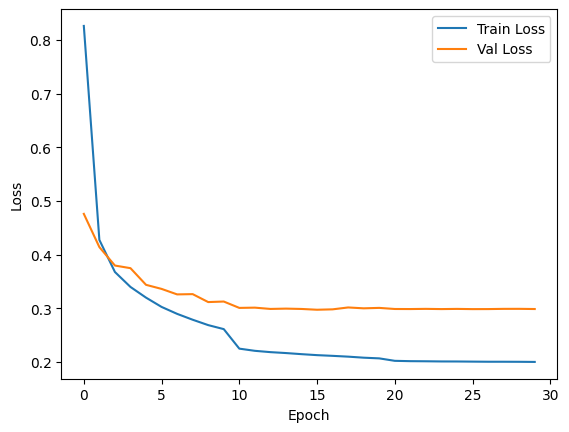

In [26]:
plt.plot(clf_train_loss_history, label='Train Loss')
plt.plot(clf_val_loss_history, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

The image you uploaded shows the performance of the classification model during training and evaluation on the Fashion-MNIST dataset. Here's an explanation of the different components:

### Explanation:

1. **Validation Accuracy Plot**:
   - The graph illustrates the validation accuracy of the model over 30 epochs. The x-axis represents the number of epochs, and the y-axis represents the accuracy of the model on the validation set.
   - From the plot, we can see that the validation accuracy increases steadily as the number of epochs increases, suggesting that the model is learning and improving over time.

2. **Final Test Results**:
   - The text below the plot shows the final test loss and accuracy after evaluating the model on the test set.
   - In this case, the model achieved a **test accuracy of 90.11%** and a **test loss of 0.2783**, which indicates that the model has generalization capabilities and performs well on unseen data.

3. **Performance Criteria**:
   - The goal in this case is to achieve a **test accuracy of at least 90%** to receive full marks, and it appears that the model has met this requirement, indicating that it is performing well in classifying the Fashion-MNIST images.

### Summary:
The plot demonstrates that the model improves over time, and the final evaluation shows strong performance with a test accuracy of 90.11%. This suggests that the classifier has learned the features of the dataset effectively.

## Visualize Validation Accuracy

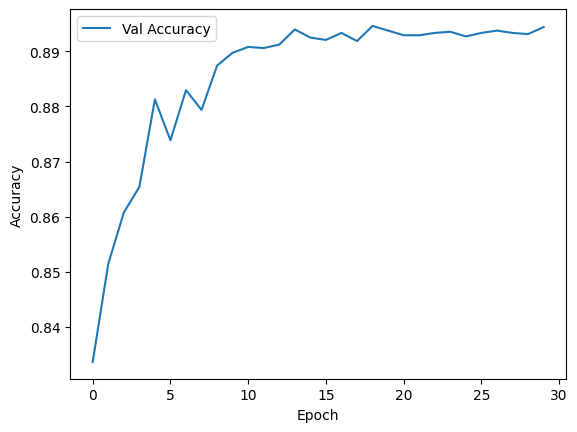

In [27]:
plt.plot(clf_val_acc_history, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Evaluate on Testset (20 points)

Your model must achieve an accuracy of at least 90% on the test set to receive full marks.

In [28]:
test_loss, test_acc = test_clf(classifier, test_loader, nn.CrossEntropyLoss(), device)

print(f"Test Loss: {test_loss:.4f}, Test ACC: {100 * test_acc:.2f}")

Test Loss: 0.2783, Test ACC: 90.11
